In [1]:
# Importing necessary libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Using Pipelines for preprocessing:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Load the uploaded NYC TRAIN dataset:
df = pd.read_parquet("../data/train_NYC_inspection.parquet")

# Display the first few rows:
df.head()

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,SCORE,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,9.0,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,9.0,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,14.0,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,40.0,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,20.0,None


In [2]:
# Handling missing values in the target column:
df = df.dropna(subset=['GRADE'])

# Separating target and features:
X = df.drop(columns=['GRADE', 'SCORE']) # Dropping 'SCORE' as well since 'SCORE' is used to allocate 'GRADE'
# Scores of A, B, C are 0-13, 14-27, 28+ respectively so must drop 'SCORE' to avoid data leakage
y = df['GRADE'] # predicting 'GRADE'

# ---- PREPROCESSING SETUP ----

# Separating numeric and categorical features:
numeric_features = ['Latitude' , 'Longitude', 'ZIPCODE']
categorical_features = ['CUISINE DESCRIPTION', 'BORO'] # REMOVING STREET/BUILDING to save memory (too many unique values if we were to one-hot encode them)

# Ensuring we have the correct features:
print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")


Numeric Features: ['Latitude', 'Longitude', 'ZIPCODE']
Categorical Features: ['CUISINE DESCRIPTION', 'BORO']


In [12]:
# ---- PIPELINES ---- 
# Using pipelines to handle preprocessing more efficiently 

# Numeric pipeline:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # imputing missing values with median for numeric
    ('scaler', StandardScaler()) # standardizing numeric features
])

# Categorical pipeline:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # imputing missing values with most frequent for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # one-hot encoding categorical features
])

# Combining both pipelines:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
])

# Putting together preprocessing and modeling together here:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(dual=False, class_weight='balanced',random_state=42)) 
    #Adding class_weight='balanced' to handle class imbalance since we have a larger number of A's compared to B's and C's
    # Helps the model understand that each grade is equally important
])

# Optimization using GridSearchCV:
param_grid = {
    'classifier__C': [0.1, 1, 10],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Printing out best parameters and best score:
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)


Best parameters found:  {'classifier__C': 0.1}
Best cross-validation score:  0.5438520092911916


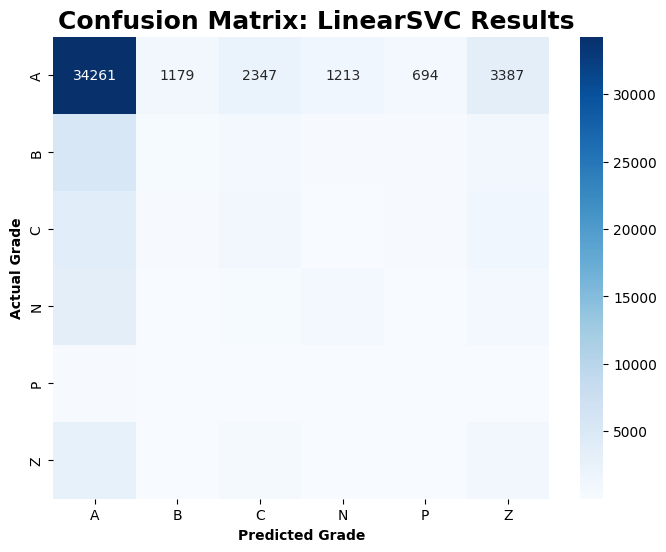

              precision    recall  f1-score   support

           A       0.69      0.80      0.74     43081
           B       0.19      0.05      0.07      8109
           C       0.19      0.15      0.17      6493
           N       0.30      0.12      0.18      5544
           P       0.01      0.06      0.02       298
           Z       0.15      0.23      0.18      4898

    accuracy                           0.55     68423
   macro avg       0.26      0.24      0.23     68423
weighted avg       0.51      0.55      0.52     68423



In [13]:
## CONFUSION MATRIX:

# Predictions:
y_pred = grid_search.predict(X)

# Confusion Matrix:
cm = confusion_matrix(y, y_pred)

# Plot:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grid_search.classes_,
            yticklabels=grid_search.classes_)

plt.xlabel('Predicted Grade', weight='bold')
plt.ylabel('Actual Grade', weight='bold')
plt.title('Confusion Matrix: LinearSVC Results', weight='bold', fontsize=18, x = 0.53)
plt.show()


print(classification_report(y, y_pred))

The model correctly predicted 'A' for 34,261 restaurants. The seemingly blank rows are for restaurants that were actually B, C, or essentially any grade other than A. Since the count of "A" grades is much higher than the others, numbers smaller than 500 are appearing as blank or white on the heatmap. Adding the 'class_weight = balanced' parameter to the model helps to address this imbalance by giving more importance to the minority classes during training.

## Explaining Data Processing Choices:

**Missing Values:** 
For dealing with missing values, we have decided to impute them using the median for numerical columns and the mode for categorical columns. This approach helps to maintain the central tendency of the data without being overly influenced by outliers. We must deal with missing values specifically for SVM, as it does not handle them natively.

**SVM Model:**
For this dataset, we decided to use the LinearSVC Model. LinearSVC is chosen because it is efficient for large datasets and works well with high-dimensional spaces. It also provides a good balance between performance and interpretability. Though we lose out on some complexity by not using the kernel trick, the linear approach is far more computationally efficient and scales better with larger datasets such as this one.



